# Aula 03 - Amostragem, Interpolação e Quantização

In [21]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 4.2 MB/s eta 0:00:11
   -- ------------------------------------- 2.4/44.0 MB 7.1 MB/s eta 0:00:06
   ---- ----------------------------------- 4.7/44.0 MB 8.6 MB/s eta 0:00:05
   ------ --------------------------------- 6.8/44.0 MB 9.1 MB/s eta 0:00:05
   -------- ------------------------------- 9.4/44.0 MB 10.1 MB/s eta 0:00:04
   ----------- ---------------------------- 12.3/44.0 MB 10.6 MB/s eta 0:00:03
   ------------- -------------------------- 15.2/44.0 MB 11.0 MB/s eta 0:00:03
   ---------------- ----------------------- 17.8/44.0 MB 11.4 MB/s eta 0:00:03
   ------------------ --------------------- 20.7/44.0 MB 11.7 MB/s eta 0:00:02
   --------------------- ------------------ 23.9/44.0 MB 11.9 MB/s eta 0:00:02
   ----------------------- ---------------- 26.0/44.0 MB 11.9 MB/s eta 0:00:02
   -------------------------- ------------- 28.8/44.0 MB 12.0 MB/s eta


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Representa e manipula matrizes
import numpy as np
# Exibe as imagens
import matplotlib.pyplot as plt
# Processamento de Imagens e Visão Computacional
import cv2


# Ler, converter, e redimensionar imagens
from PIL import Image
# Acessa imagens de exemplo
from skimage import data, color

In [3]:
def mostrar_imagem(imagem, titulo, cmap=None, barra_cores=False, tamanho=(4,4)):
    # Definindo Tamanho da imagem
    plt.figure(figsize=tamanho);

    plt.imshow(imagem, cmap=cmap, vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis("off")

    if barra_cores:
        plt.colorbar()

    plt.show()

def mostrar_comparacao(imagens, titulos, cmaps=None, tamanho=(16, 6)):
    quantidade = len(imagens)

    if cmaps is None:
        cmaps = [None] * quantidade

    fig, eixos = plt.subplots(1, quantidade, figsize=tamanho)

    if quantidade == 1:
        eixos = [eixos]

    for eixo, imagem, titulo, cmap in zip(eixos, imagens, titulos, cmaps):
        eixo.imshow(imagem, cmap=cmap)
        eixo.set_title(titulo)
        eixo.axis("off")

    plt.tight_layout()
    plt.show()

def mostrar_imagem_histograma(imagem, titulo="Imagem"):
    fig, eixos = plt.subplots(1, 2, figsize=(16,6))

    eixos[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
    eixos[0].set_title(titulo)
    eixos[0].axis("off")

    eixos[1].hist(
        imagem.ravel(),
        bins = 256,
        range = (0, 255)
    )
    eixos[1].set_title("Histograma")
    eixos[1].set_xlabel("Intensidade")
    eixos[1].set_ylabel("Quantidade de Pixels")

    plt.show()

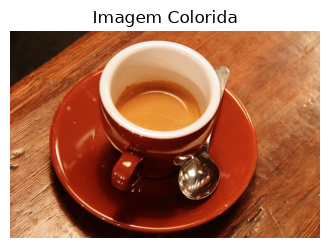

Dimensões: (400, 600, 3)
Tipo de Dado: uint8


In [4]:
imagem_rgb = data.coffee()

mostrar_imagem(
    imagem_rgb,
    titulo="Imagem Colorida"
)

print("Dimensões:", imagem_rgb.shape)
print("Tipo de Dado:", imagem_rgb.dtype)

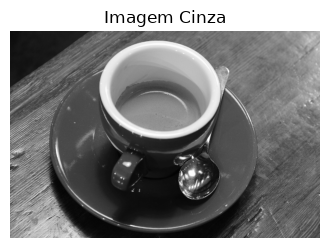

In [5]:
imagem_float = imagem_rgb

cinza_media = imagem_float.mean(axis=2).astype(np.uint8)
mostrar_imagem(
    cinza_media,
    titulo="Imagem Cinza",
    cmap="gray"
)

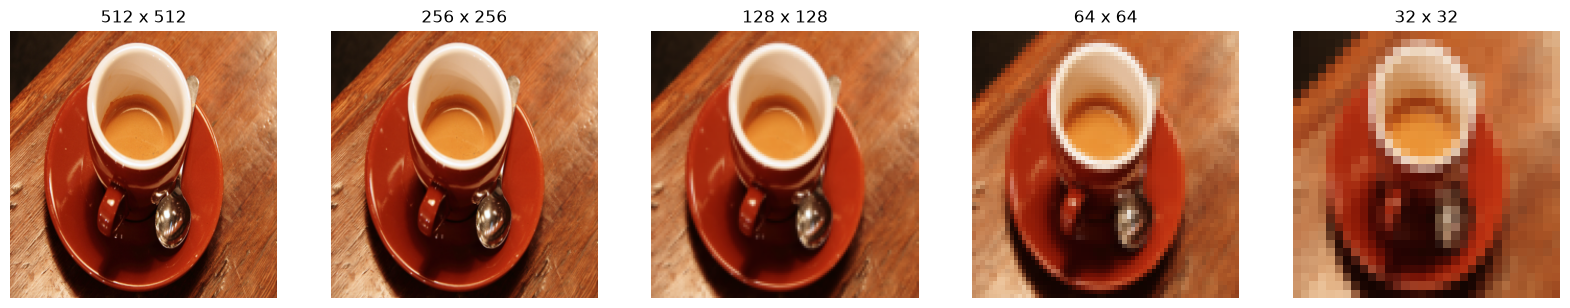

In [ ]:
# Amostragem - Determina quantidade de pontos utilizados pra representar uma imagem.

# REDUZINDO O TAMANHO DA IMAGEM

# Convertendo a imagem para uma forma em que o PILL trabalha
imagem_pil = Image.fromarray(imagem_rgb)

tamanhos = [
    (512, 512),
    (256, 256),
    (128, 128),
    (64, 64),
    (32, 32)
]

# fig - Representa a imagem completa
# eixos - Array de posições dentro da imagem
fig, eixos = plt.subplots(1, 5, figsize=(20,5))

for eixos, tamanho in zip(eixos, tamanhos):
    reduzida = imagem_pil.resize(
        tamanho,
        Image.Resampling.BILINEAR
    )

    # Definindo configurações para cada um dos eixos
    eixos.imshow(reduzida)
    eixos.set_title(f"{tamanho[0]} x {tamanho[1]}")
    eixos.axis("off")

plt.show()

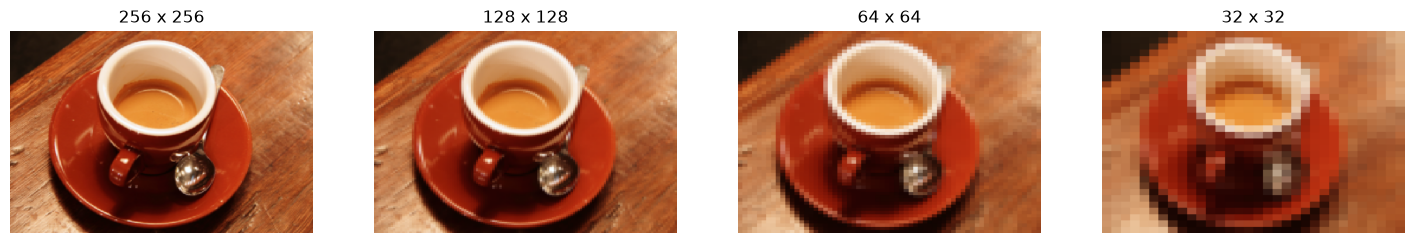

(600, 400)


In [ ]:
# REDUZINDO A QUALIDADE DA IMAGEM

# Pegando o tamanho da imagem pra armazenar 
tamanho_original = imagem_pil.size

resolucoes = [256, 128, 64, 32]


fig, eixos = plt.subplots(1, len(resolucoes), figsize=(18,5))

for eixos, resolucoes in zip(eixos, resolucoes):
    reduzida = imagem_pil.resize(
        (resolucoes, resolucoes),
        Image.Resampling.BILINEAR
    )

    ampliada = reduzida.resize(
        tamanho_original,
        Image.Resampling.NEAREST
    )

    # Definindo configurações para cada um dos eixos
    eixos.imshow(ampliada)
    eixos.set_title(f"{resolucoes} x {resolucoes}")
    eixos.axis("off")
    
plt.show()

print(imagem_pil.size)

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

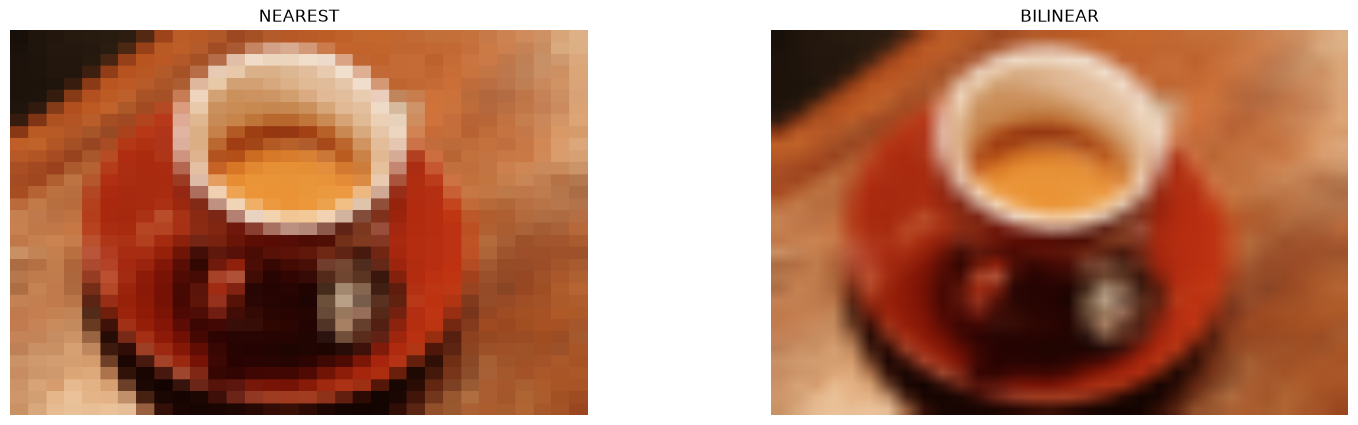

In [ ]:
reduzida = imagem_pil.resize(
    (32, 32),
    Image.Resampling.BILINEAR
    # Image.Resampling.NEAREST
)

ampliada_1 = reduzida.resize(
    tamanho_original,
    Image.Resampling.NEAREST
)

ampliada_2 = reduzida.resize(
    tamanho_original,
    Image.Resampling.BILINEAR
)

fig, eixos = plt.subplots(1, 2, figsize=(18,5))

# Definindo configurações para cada um dos eixos
eixos[0].imshow(ampliada_1)
eixos[0].set_title(f"NEAREST")
eixos[0].axis("off")

eixos[1].imshow(ampliada_2)
eixos[1].set_title(f"BILINEAR")
eixos[1].axis("off")

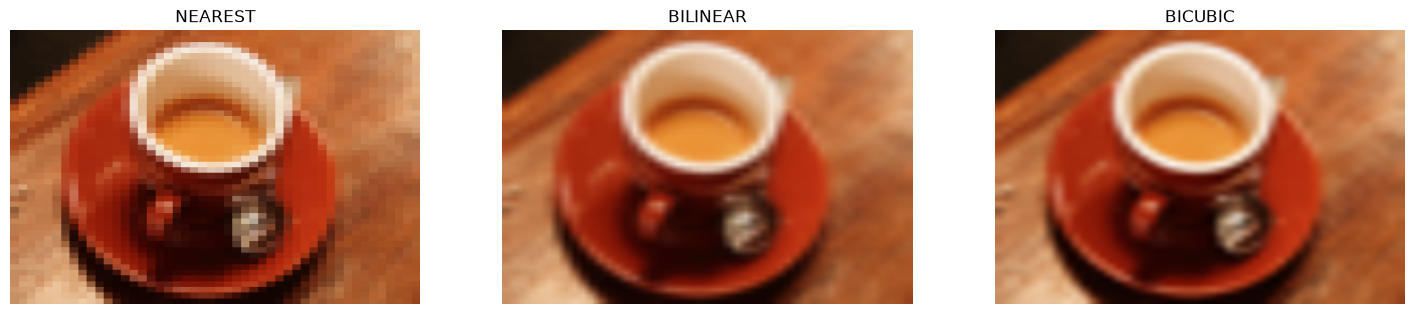

In [19]:
imagem_reduzida = imagem_pil.resize(
    (48,48),
    Image.Resampling.BILINEAR
)

metodos = {
    "NEAREST": Image.Resampling.NEAREST,
    "BILINEAR": Image.Resampling.BILINEAR,
    "BICUBIC": Image.Resampling.BICUBIC,
}

fig, eixos = plt.subplots(1, 3, figsize=(18,6))

for eixo, (nome, metodo) in zip(eixos, metodos.items()):
    ampliada = imagem_reduzida.resize(
        tamanho_original,
        metodo
    )

    eixo.imshow(ampliada)
    eixo.set_title(nome)
    eixo.axis("off")

plt.show()

In [5]:
# QUANTIZAÇÃO
# Refere-se a quantos níveis podem ser utilizados para representar uma imagem

def quantizacao(imagem, quantidade_niveis):

    # Passando a imagem para intervalo de 0 ... 1
    imagem_normalizada = imagem.astype(np.float32) / 255.0

    # Arredondando os valores para cada um dos níveis
    indice = np.round(
        imagem_normalizada * (quantidade_niveis - 1)
    )

    # Passando a imagem para o intervalo de 0 ... 255
    quantizada = (
        indice / (quantidade_niveis - 1 ) * 255
    )

    return quantizada.astype(np.uint8)


TypeError: 'int' object is not subscriptable

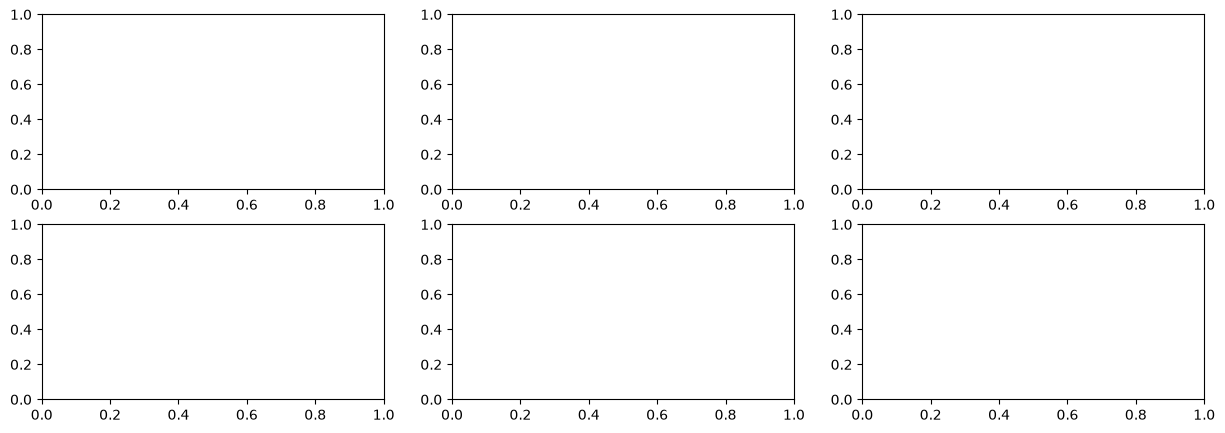

In [ ]:
niveis = [256, 32, 16, 8, 4, 2]

fig, eixos = plt.subplots(2, 3, figsize=(15,5))

# ravel() - Transforma matriz em um vetor
for eixo, quantidade in zip([0,0,2,2,4,4], niveis):
    quantizada = quantizacao(
        cinza_media,
        quantidade 
    )

    eixo.imshow(quantizada, cmap="gray")
    eixo.set_title(f"{quantidade}")
    eixo.axis('off')

plt.show()

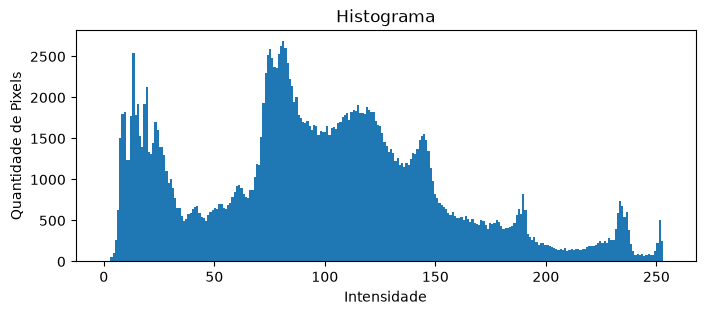

In [18]:
# HISTOGRAMA
plt.figure(figsize=(8,3))
plt.hist(
    # Imagem Utilizada
    cinza_media.ravel(),
    # Variância
    bins=256,
    # Intervalo
    range=(0, 255)
)

plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de Pixels")
plt.show()

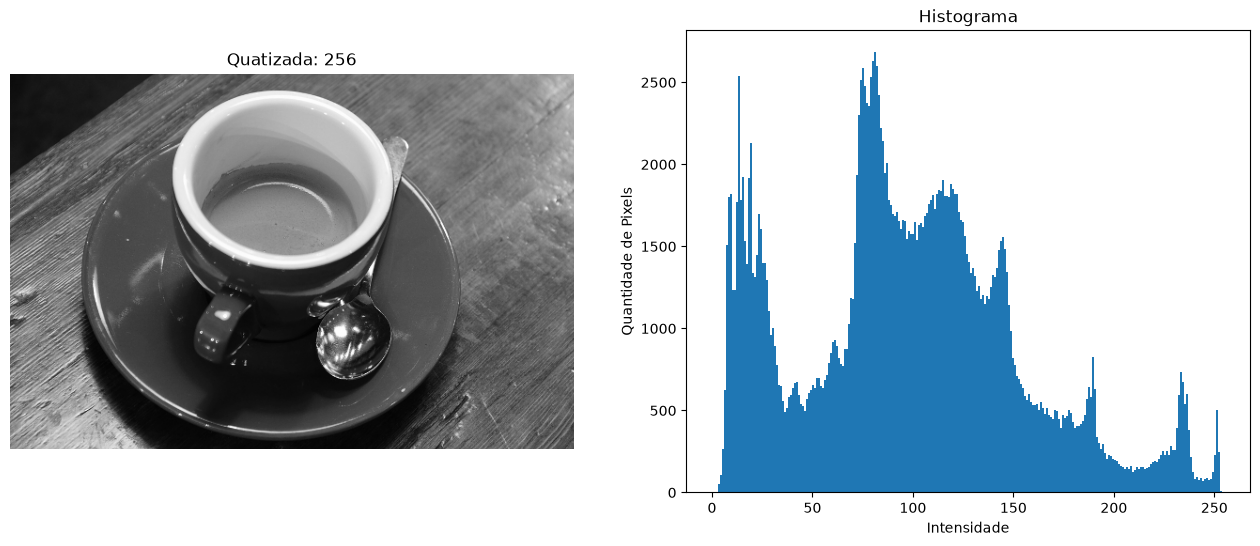

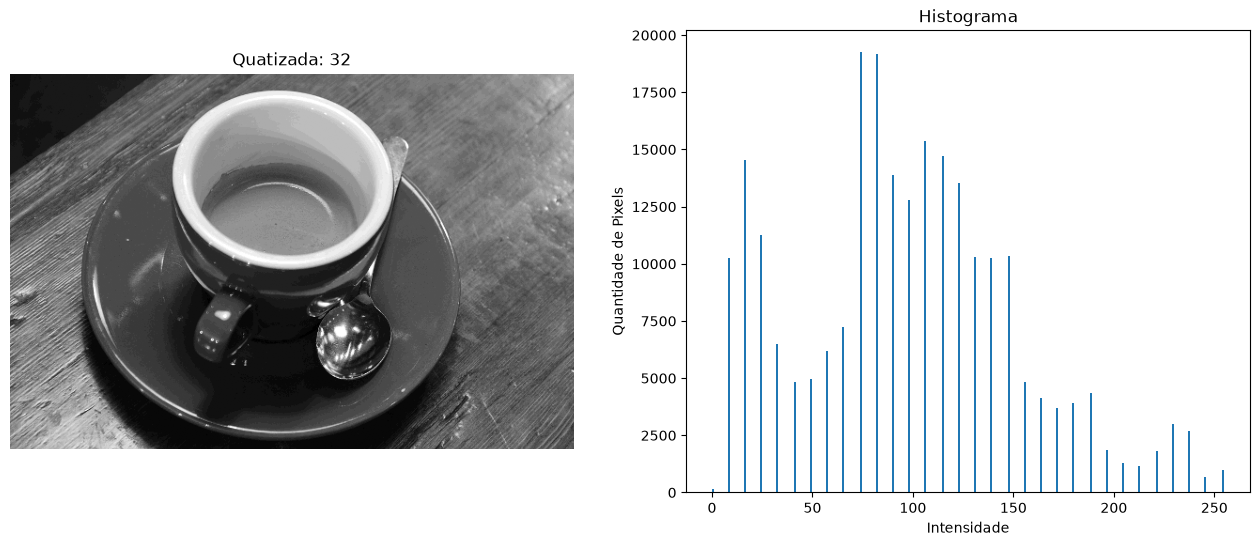

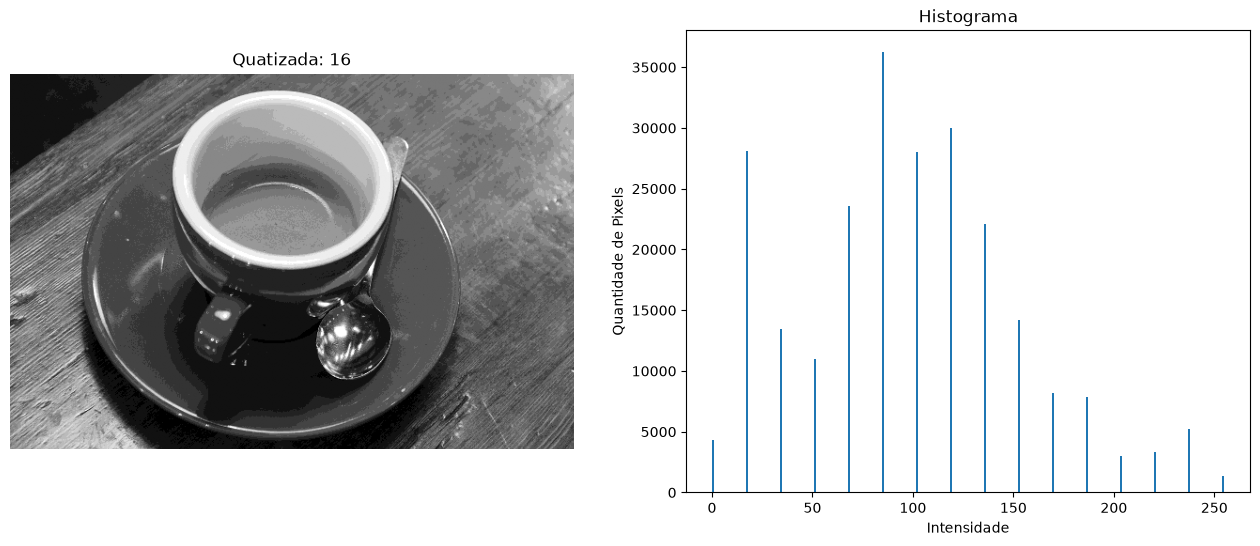

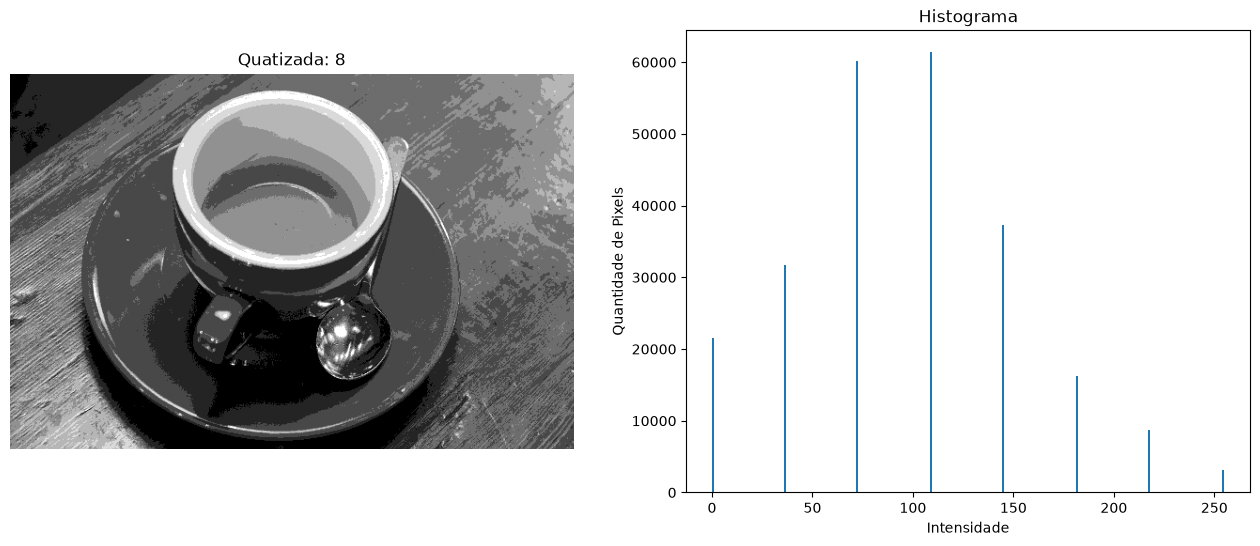

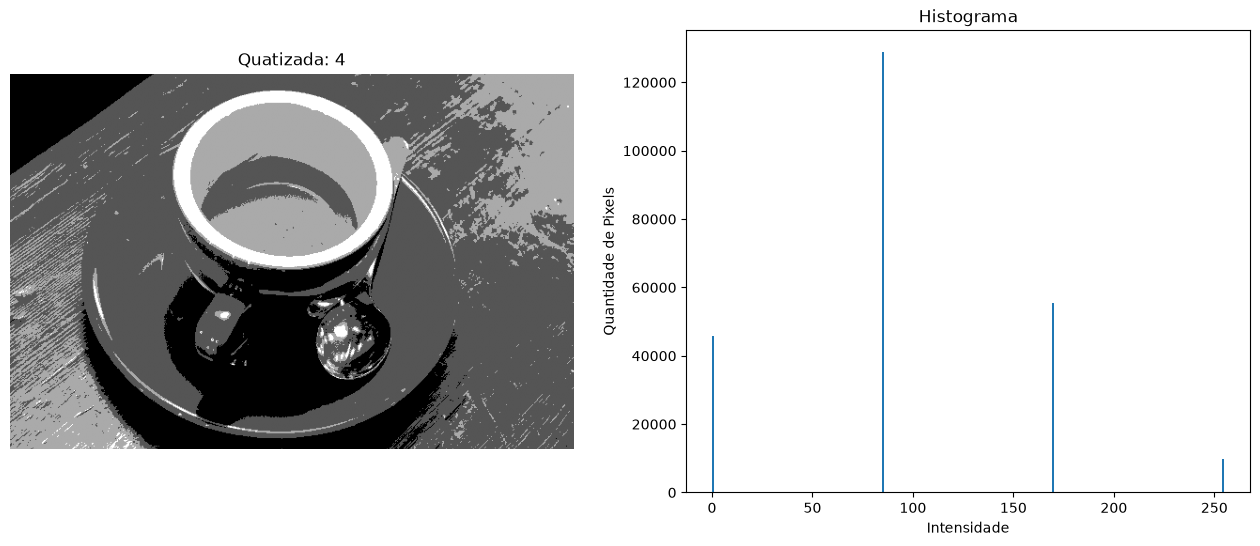

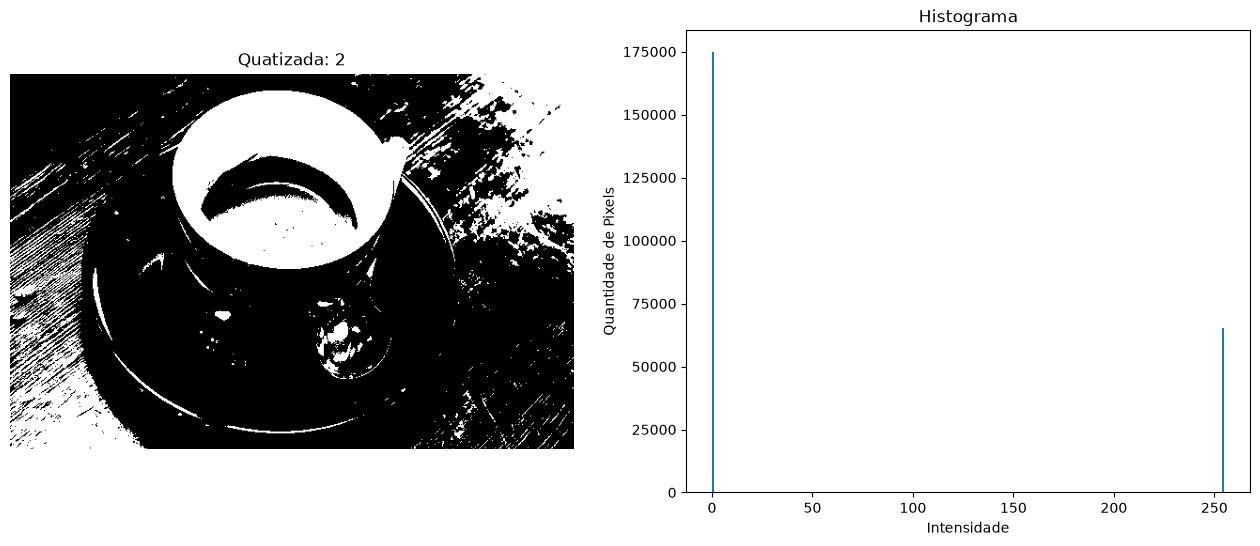

In [23]:
niveis = [256, 32, 16, 8, 4, 2]
# ravel() - Transforma matriz em um vetor
for quantidade in niveis:
    quantizada = quantizacao(
        cinza_media,
        quantidade 
    )

    mostrar_imagem_histograma(quantizada, f"Quatizada: {quantidade}")



In [6]:
def ajustar_brilho(imagem, valor):
    imagem_int = imagem.astype(np.int16)

    # Alterar o brilho, é só pegar o valor do pixel e somar o valor de aumento
    resultado = np.clip(
        imagem_int + valor,
        0,
        255
    )

    return resultado.astype(np.uint8)

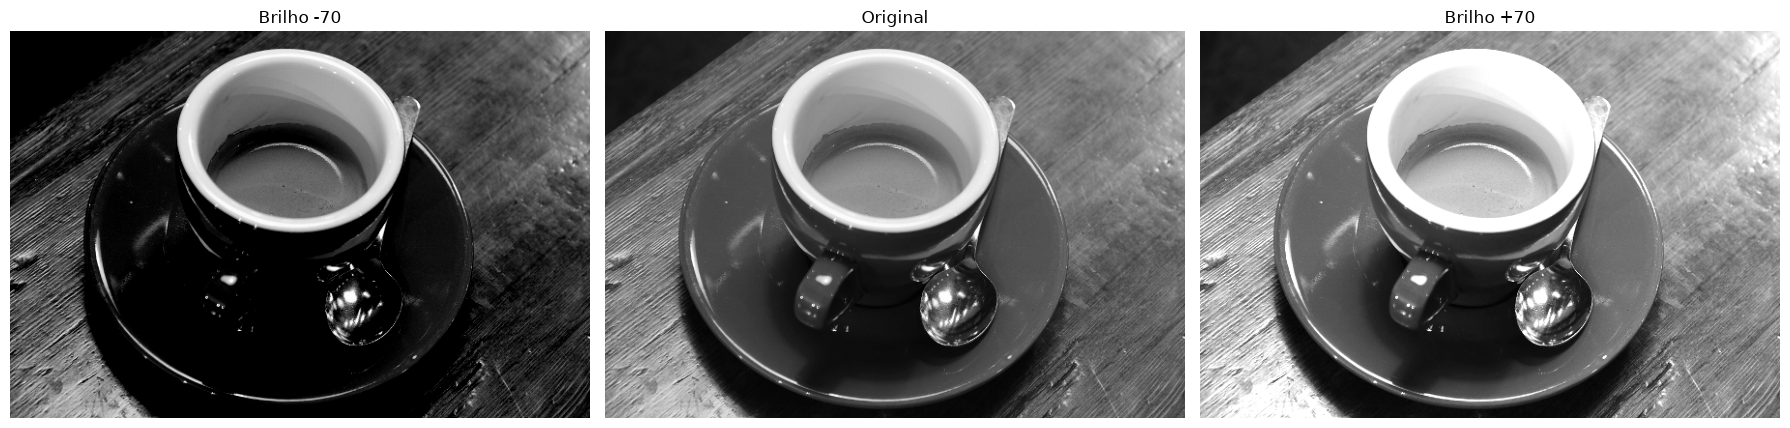

In [7]:
mais_escura = ajustar_brilho(cinza_media, -70)
mais_clara = ajustar_brilho(cinza_media, 70)

mostrar_comparacao(
    [mais_escura, cinza_media, mais_clara],
    ["Brilho -70", "Original", "Brilho +70"],
    ["gray", "gray", "gray"],
    tamanho=(18, 6)
)

In [9]:
def ajustar_contraste(imagem, alfa=1.0, beta=0):
    imagem_float = imagem.astype(np.float32)

    # Para alterar o contraste da imagem
    # alfa aumenta o contraste
    # beta aumenta o brilho
    resultado = alfa * imagem_float + beta

    return np.clip(
        resultado,
        0,
        255
    ).astype(np.uint8)

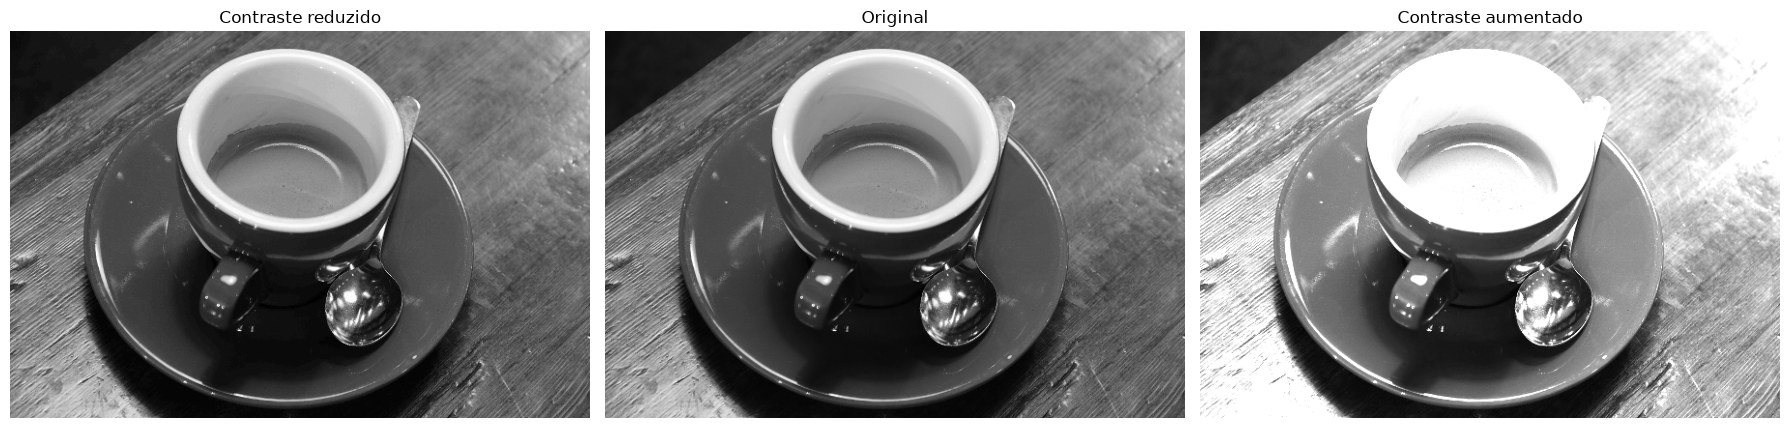

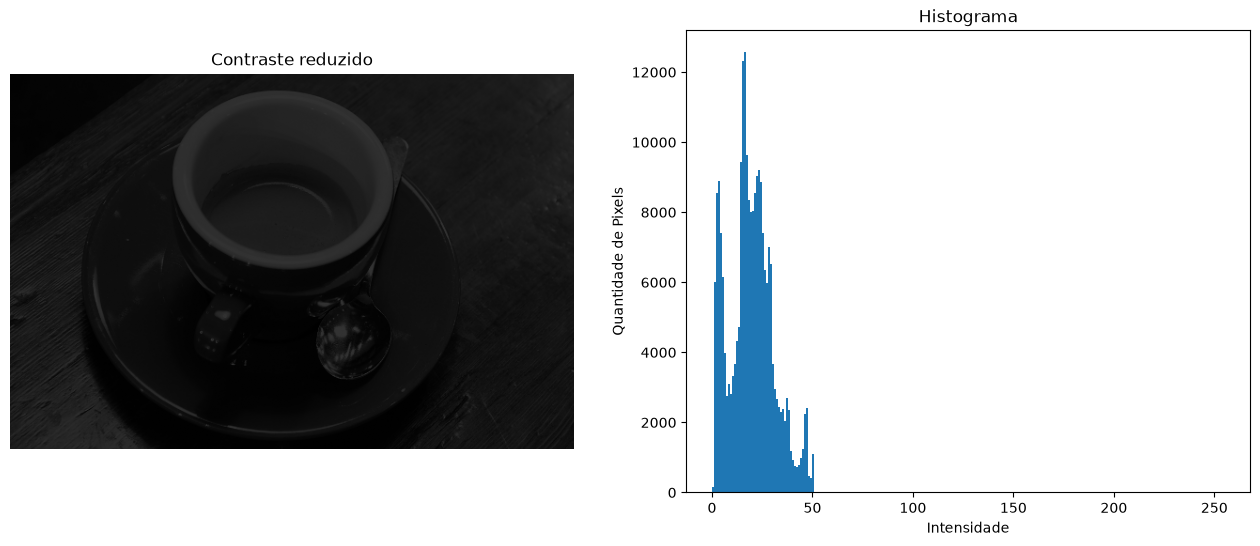

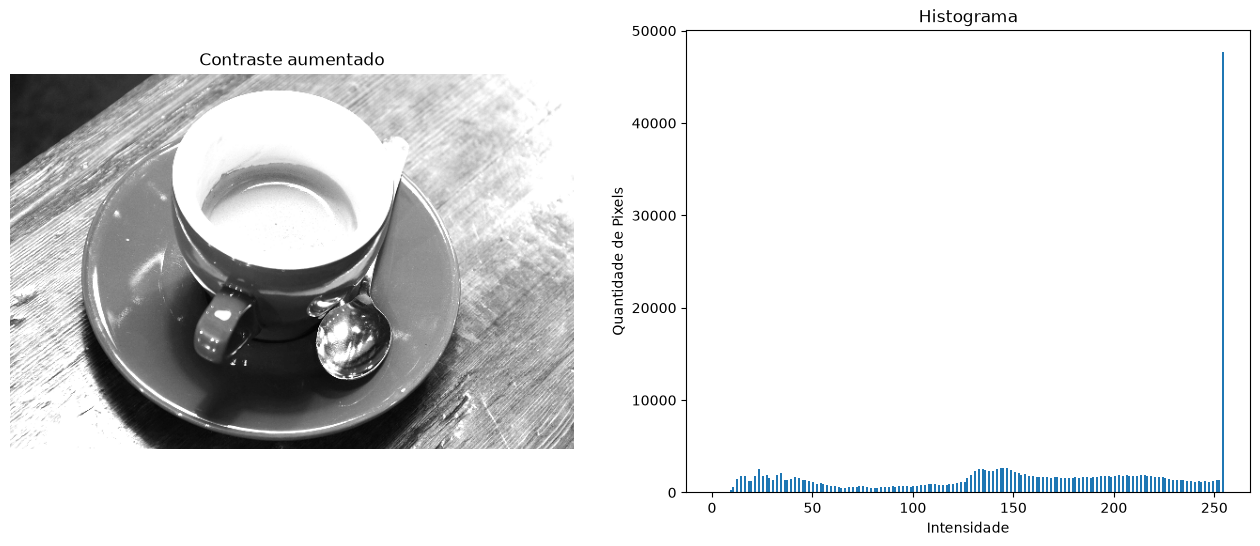

In [11]:
baixo_contraste = ajustar_contraste(cinza_media, alfa=0.2, beta=0)
alto_contraste = ajustar_contraste(cinza_media, alfa=1.8, beta=0)

mostrar_comparacao(
    [baixo_contraste, cinza_media, alto_contraste],
    ["Contraste reduzido", "Original", "Contraste aumentado"],
    ["gray", "gray", "gray"],
    tamanho=(18, 6)
)

mostrar_imagem_histograma(
    baixo_contraste,
    "Contraste reduzido"
)

mostrar_imagem_histograma(
    alto_contraste,
    "Contraste aumentado"
)

In [12]:
def correcao_gama(imagem, gamma):
    if gamma <= 0:
        raise ValueError("Gamma deve ser maior que zero.")

    # Correção do Gama é aplicado de maneira normalizada 0...1
    normalizada = imagem.astype(np.float32) / 255.0

    # elevando a um número, normalizada ** gamma
    corrigida = np.power(
        normalizada,
        gamma
    )

    # Garantindo os valores ficarem de 0 a 255
    return np.clip(
        corrigida * 255,
        0,
        255
    ).astype(np.uint8)

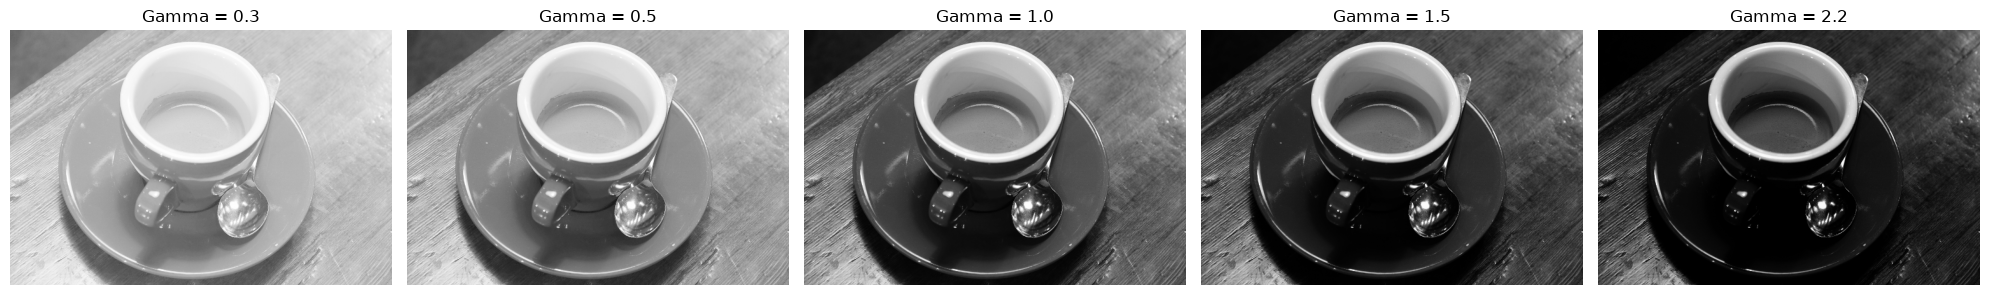

In [14]:
gammas = [0.3, 0.5, 1.0, 1.5, 2.2]

fig, eixos = plt.subplots(1, len(gammas), figsize=(20, 5))

for eixo, gamma in zip(eixos, gammas):
    resultado = correcao_gama(cinza_media, gamma)

    eixo.imshow(resultado, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(f"Gamma = {gamma}")
    eixo.axis("off")

plt.tight_layout()
plt.show()

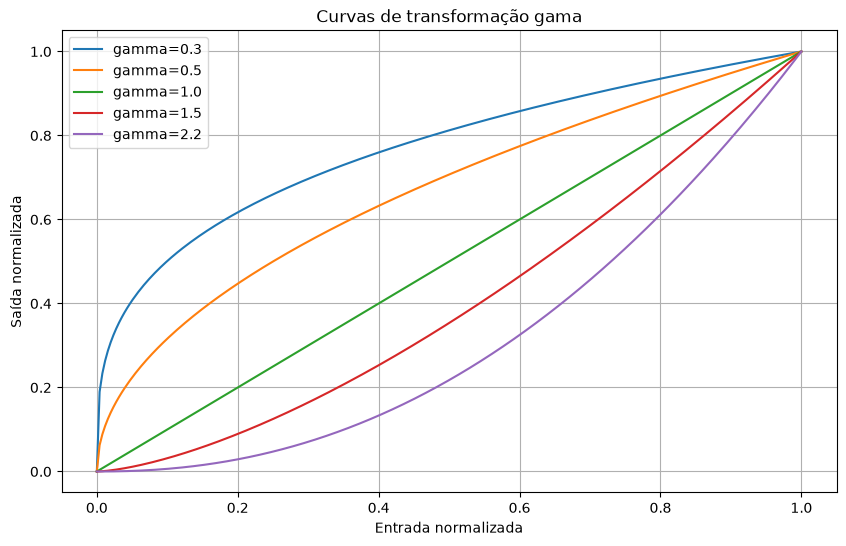

In [15]:
#  Criando 256 valores espacados entre 0 e 1
valores = np.linspace(0, 1, 256)

plt.figure(figsize=(10, 6))

for gamma in [0.3, 0.5, 1.0, 1.5, 2.2]:
    # Função de Gráfico
    # Eixo x recebe os valores,
    # Eixo y recebe os valores elevados ao gamma
    # crio uma legenda
    plt.plot(
        valores,
        valores ** gamma,
        label=f"gamma={gamma}"
    )

plt.title("Curvas de transformação gama")
plt.xlabel("Entrada normalizada")
plt.ylabel("Saída normalizada")
plt.legend()
plt.grid()
plt.show()

In [29]:
def alongar_contraste(imagem):
    minimo = float(imagem.min())
    maximo = float(imagem.max())

    if maximo == minimo:
        return np.zeros_like(imagem)

    resultado = (
        (imagem.astype(np.float32) - minimo) /
        (maximo - minimo)
    ) * 255

    return np.clip(resultado, 0, 255).astype(np.uint8)

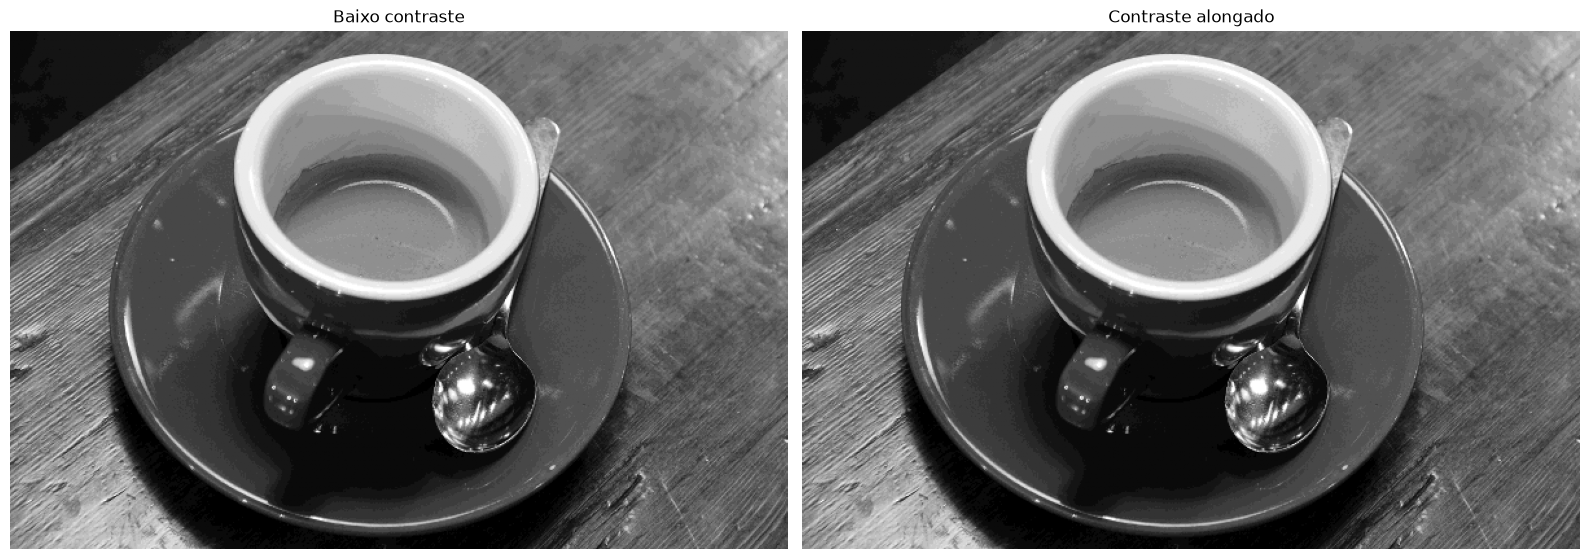

In [17]:
baixo_contraste_real = ajustar_contraste(
    cinza_media,
    alfa=0.1,
    beta=0
)

alongada = alongar_contraste(baixo_contraste_real)


mostrar_comparacao(
    [baixo_contraste_real, alongada],
    ["Baixo contraste", "Contraste alongado"],
    ["gray", "gray"]
)

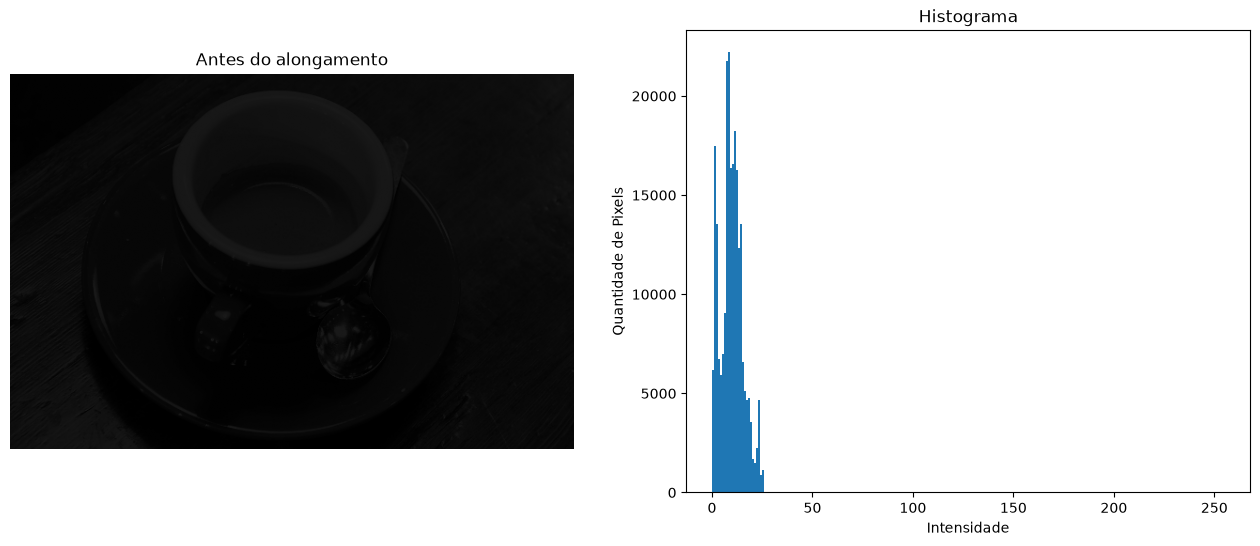

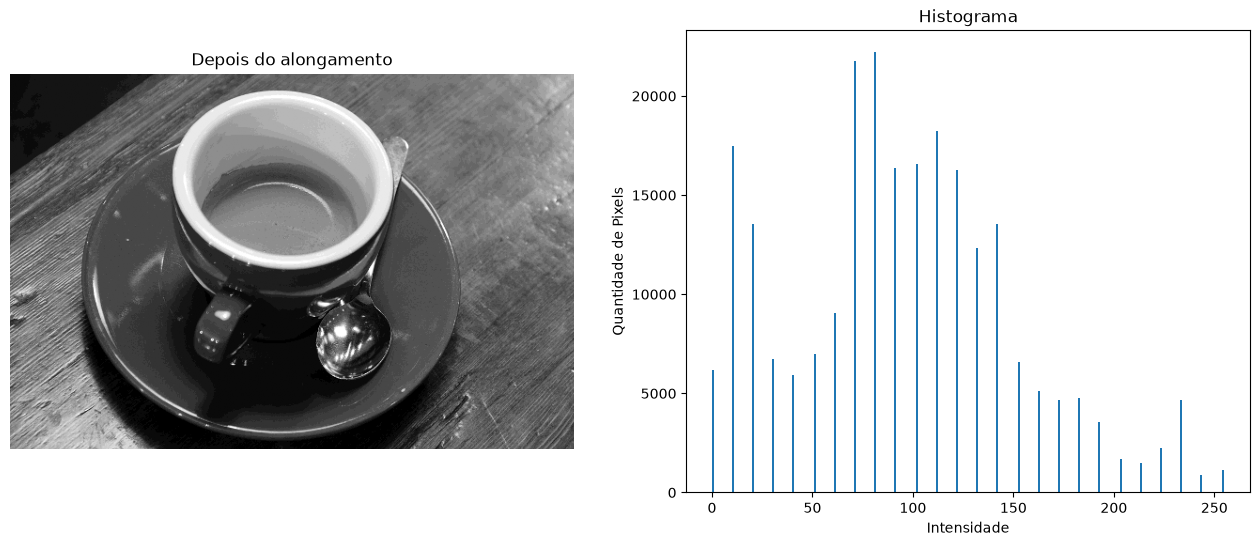

In [30]:
mostrar_imagem_histograma(
    baixo_contraste_real,
    "Antes do alongamento"
)

mostrar_imagem_histograma(
    alongada,
    "Depois do alongamento"
)

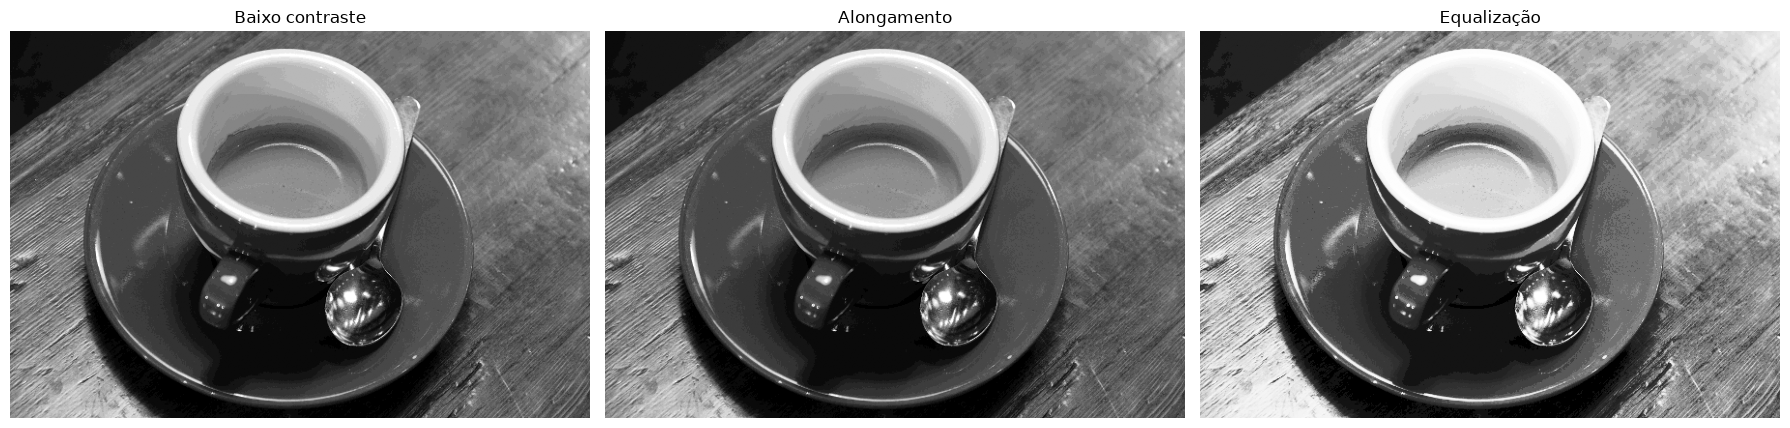

In [25]:
equalizada = cv2.equalizeHist(
    baixo_contraste_real
)

mostrar_comparacao(
    [baixo_contraste_real, alongada, equalizada],
    ["Baixo contraste", "Alongamento", "Equalização"],
    ["gray", "gray", "gray"],
    tamanho=(18, 6)
)

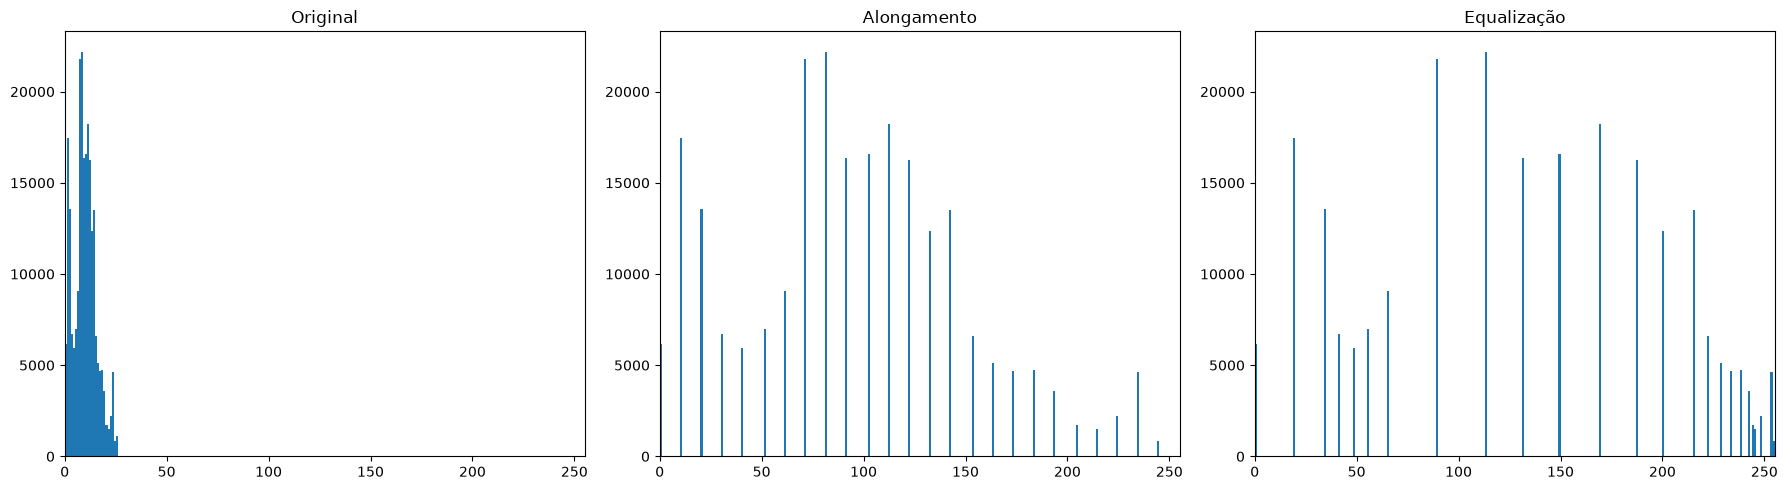

In [26]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

for eixo, imagem, titulo in zip(
    eixos,
    [baixo_contraste_real, alongada, equalizada],
    ["Original", "Alongamento", "Equalização"]
):
    eixo.hist(
        imagem.ravel(),
        bins=256,
        range=(0, 256)
    )
    eixo.set_title(titulo)
    eixo.set_xlim(0, 255)

plt.tight_layout()
plt.show()

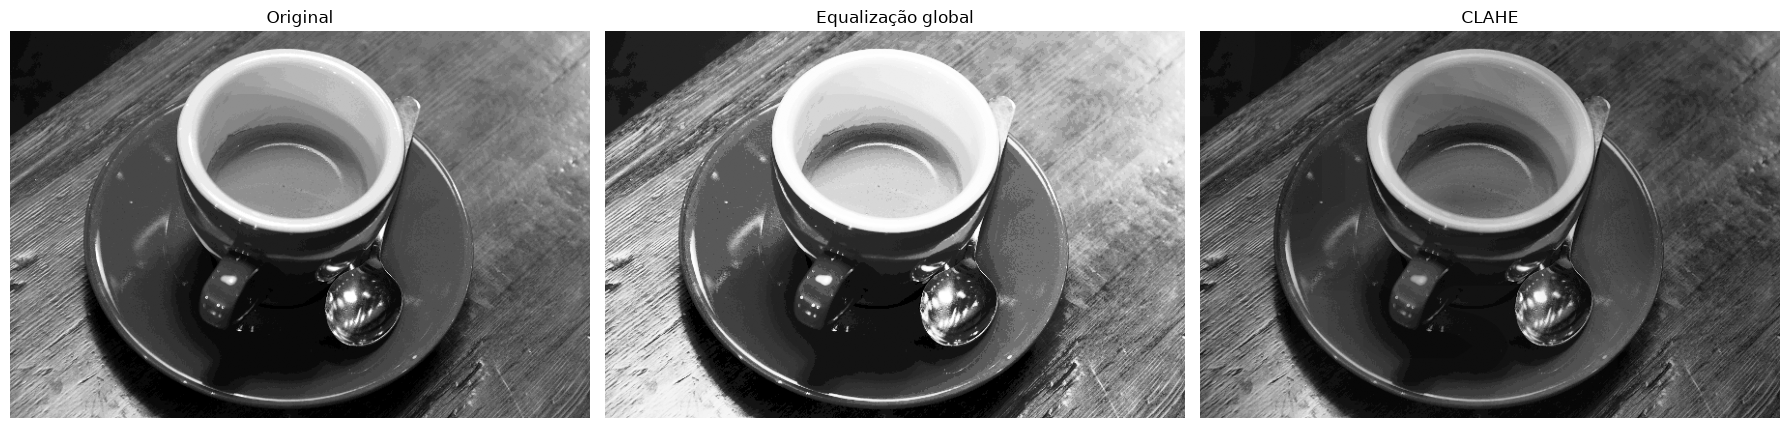

In [27]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

resultado_clahe = clahe.apply(
    baixo_contraste_real
)

mostrar_comparacao(
    [baixo_contraste_real, equalizada, resultado_clahe],
    ["Original", "Equalização global", "CLAHE"],
    ["gray", "gray", "gray"],
    tamanho=(18, 6)
)